In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

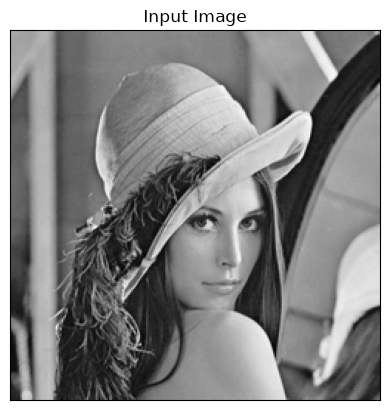

In [2]:
img_path = "../../images/lenna.png"
img = cv.imread(img_path, 0).astype(np.float64)

M, N = img.shape

# Distance of every point from the centre
u, v = np.meshgrid(np.arange(N) - N / 2, np.arange(M) - M / 2)
D = np.sqrt(u**2 + v**2)

IMG = np.fft.fftshift(np.fft.fft2(img))


def out_of_focus_H(radius):
    psf = np.zeros((M, N), dtype=np.float32)
    cv.circle(psf, (N // 2, M // 2), radius, 1, -1)
    psf /= psf.sum()
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(psf)))


plt.imshow(img, cmap="gray")
plt.title("Input Image")
plt.xticks([]), plt.yticks([])
plt.show()

1. Apply a Gaussian blur to the input image to obtain the degraded image. To this degraded image,
apply inverse filter and comment on the observed output.

Gaussian blur in the frequency domain is modeled by $H = e^{-D^2/2D_0^2}$, so degrading the image
means $G = F \cdot H$. The inverse filter simply undoes this multiplication:
$\hat F = G / H$, which is exact whenever $H$ is known exactly and there is no noise.

In [ ]:
D0 = 10  # larger D0 -> weaker blur (H stays close to 1 over more frequencies)
H = np.exp(-(D**2) / (2 * D0**2))

# Step 1: Degrade with Gaussian blur
G = IMG * H
g = np.fft.ifft2(np.fft.ifftshift(G))

# Step 2: Apply inverse filter
F_hat = np.nan_to_num(G / H)
f_hat = np.fft.ifft2(np.fft.ifftshift(F_hat))

plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1), plt.imshow(img, cmap="gray"), plt.title("Input Image"), plt.xticks([]), plt.yticks([])
plt.subplot(1, 4, 2), plt.imshow(H, cmap="gray"), plt.title("PSF"), plt.xticks([]), plt.yticks([])
plt.subplot(1, 4, 3), plt.imshow(np.abs(g), cmap="gray"), plt.title("Blurred Image"), plt.xticks([]), plt.yticks([])
plt.subplot(1, 4, 4), plt.imshow(np.abs(f_hat), cmap="gray"), plt.title("Restored Image"), plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()

Comment: with no noise present, dividing by H exactly undoes the Gaussian blur wherever H is
non-zero, so the restored image is visually identical to the input. The inverse filter is only
this well-behaved because the degradation is noise-free - any noise added to the blurred image
would get amplified wherever H is small, as seen in the experiments below.

2. Demonstrate the impact of choosing the wrong parameter in the restoration filter. Degrade the
image with a Gaussian blur of variance 10. Restore the image assuming variance is 5 instead of 10.

The inverse filter's correctness depends entirely on knowing the true $H$. Here the image is
blurred using $D_0 = 10$ but restored assuming $D_0 = 5$, so the restoration mask no longer
matches the actual degradation and cannot fully undo it.

In [ ]:
D0_true, D0_wrong = 10, 5  # D0_true sets the actual blur strength; using a smaller D0_wrong under-corrects it, leaving residual blur

H_true = np.exp(-(D**2) / (2 * D0_true**2))
H_wrong = np.exp(-(D**2) / (2 * D0_wrong**2))

G = IMG * H_true
g = np.fft.ifft2(np.fft.ifftshift(G))

F_hat = np.nan_to_num(G / H_wrong)
f_hat = np.fft.ifft2(np.fft.ifftshift(F_hat))

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img, cmap="gray"), plt.title("Input Image"), plt.xticks([]), plt.yticks([])
plt.subplot(1, 3, 2), plt.imshow(np.abs(g), cmap="gray"), plt.title("Blurred (variance=10)"), plt.xticks([]), plt.yticks([])
plt.subplot(1, 3, 3), plt.imshow(np.abs(f_hat), cmap="gray"), plt.title("Restored (assumed variance=5)"), plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()

Comment: the narrower assumed PSF (variance 5) under-corrects the true, wider blur (variance 10),
since it boosts high frequencies far less aggressively than required. The restored image stays
visibly blurred instead of being sharpened back to the original, showing that inverse filtering
is sensitive to accurate knowledge of the degradation parameters.

3. Apply inverse filtering for Out-of-Focus Blur.

Out-of-focus blur is modeled by convolving with a uniform disk PSF; its frequency response $H$
is obtained by taking the FFT of that disk kernel. As before, inverse filtering divides the
blurred spectrum by $H$: $\hat F = G / H$.

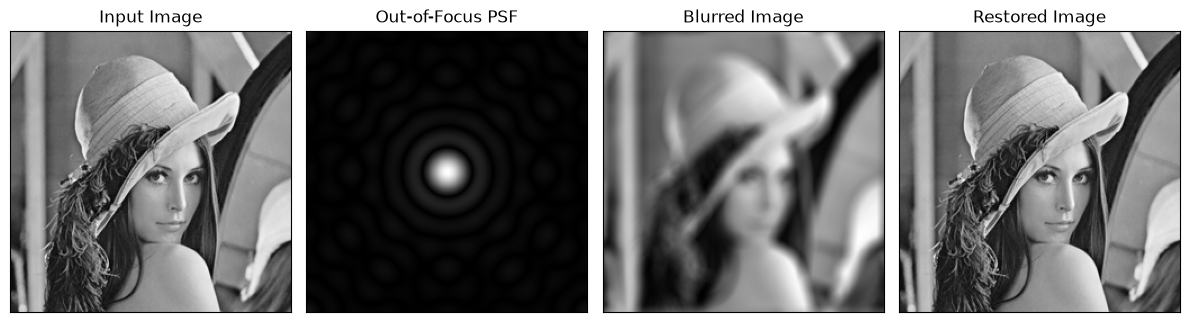

In [10]:
H = out_of_focus_H(radius=7)  # larger radius -> stronger, more spread-out blur

G = IMG * H
g = np.fft.ifft2(np.fft.ifftshift(G))

F_hat = np.nan_to_num(G / H)
f_hat = np.fft.ifft2(np.fft.ifftshift(F_hat))

plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1), plt.imshow(img, cmap="gray"), plt.title("Input Image"), plt.xticks([]), plt.yticks([])
plt.subplot(1, 4, 2), plt.imshow(np.abs(H), cmap="gray"), plt.title("Out-of-Focus PSF"), plt.xticks([]), plt.yticks([])
plt.subplot(1, 4, 3), plt.imshow(np.abs(g), cmap="gray"), plt.title("Blurred Image"), plt.xticks([]), plt.yticks([])
plt.subplot(1, 4, 4), plt.imshow(np.abs(f_hat), cmap="gray"), plt.title("Restored Image"), plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()

4. Blur the image with Gaussian blur. Add Gaussian noise. Apply Inverse filter to the blurred and
noisy version of the image.

Once noise is added after blurring, the spectrum becomes $G = F \cdot H + N$, so
$G / H = F + N / H$. Wherever $|H|$ is small, the noise term $N / H$ is amplified, corrupting the
inverse-filtered result even though the blur itself is mild and would otherwise be easy to undo.

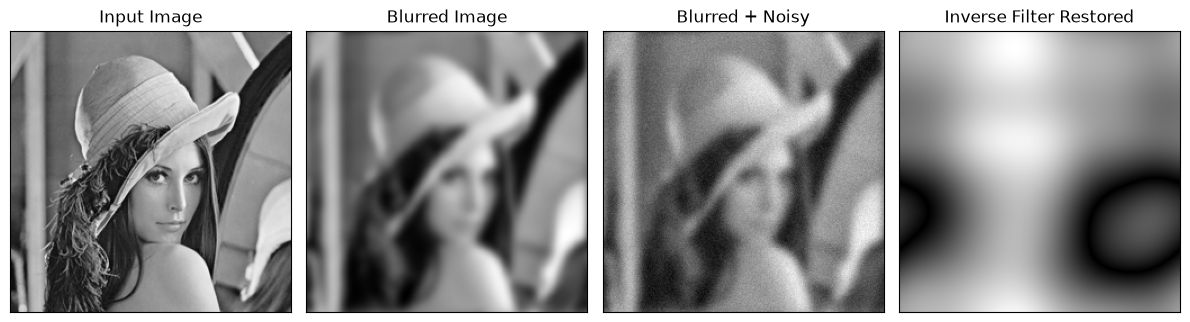

In [11]:
D0 = 10  # larger D0 -> weaker blur to restore from
H = np.exp(-(D**2) / (2 * D0**2))

g_clean = np.abs(np.fft.ifft2(np.fft.ifftshift(IMG * H)))

noise = np.random.normal(0, 5, img.shape)
g_noisy = g_clean + noise

G_noisy = np.fft.fftshift(np.fft.fft2(g_noisy))

F_hat = np.nan_to_num(G_noisy / H)
f_hat = np.fft.ifft2(np.fft.ifftshift(F_hat))

plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1), plt.imshow(img, cmap="gray"), plt.title("Input Image"), plt.xticks([]), plt.yticks([])
plt.subplot(1, 4, 2), plt.imshow(g_clean, cmap="gray"), plt.title("Blurred Image"), plt.xticks([]), plt.yticks([])
plt.subplot(1, 4, 3), plt.imshow(g_noisy, cmap="gray"), plt.title("Blurred + Noisy"), plt.xticks([]), plt.yticks([])
plt.subplot(1, 4, 4), plt.imshow(np.abs(f_hat), cmap="gray"), plt.title("Inverse Filter Restored"), plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()

Comment: the inverse filter divides by H at every frequency, including the high frequencies where
H is close to zero. Since noise has roughly equal energy at all frequencies, this division
amplifies the noise far more than the signal there, so the restored image is dominated by
high-frequency noise artifacts despite the blur itself being mild. This motivates using the
Wiener filter, which accounts for the noise-to-signal ratio instead of inverting H directly.

5. Application of Wiener Filter to an Image that is Corrupted by Gaussian Noise and Degraded by
Out-of-Focus Blur.

Step 1: The input image that is free from noise and degradation is read.
Step 2: Out-of-focus blur with radius R = 7 is generated.
Step 3: The Fourier transform of the noise-free image and out-of-focus blur function are taken.
Step 4: In order to create a blurred image, the results of Step 3 are multiplied, and the inverse
Fourier transform is computed.
Step 5: In order to create a noisy image, the result of Step 4 is corrupted by additive white
Gaussian noise with zero mean and variance = 10.
Step 6: The Fourier transform of noisy image is taken.
Step 7: Wiener filter is obtained with K = 0.03, where "K" represents noise-to-signal ratio.
Step 8: The results of Steps 6 and 7 are multiplied, and the inverse Fourier transform is used to
obtain the restored image.

The Wiener filter improves on the plain inverse filter by weighting the restoration according to
the expected noise level: $\hat F = \dfrac{H^*}{|H|^2 + K} G$. A small $K$ makes it behave like
the inverse filter; a larger $K$ suppresses noise amplification at the cost of some blur
remaining in the result.

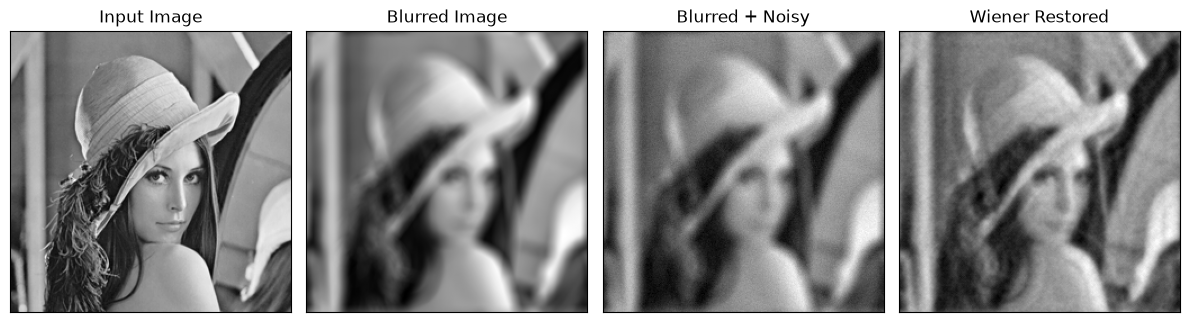

In [12]:
# Steps 1-3: noise-free image, out-of-focus PSF, and their spectra
H = out_of_focus_H(radius=7)  # larger radius -> stronger blur to restore from

# Step 4: blurred image
g = np.abs(np.fft.ifft2(np.fft.ifftshift(IMG * H)))

# Step 5: add Gaussian noise, mean 0, variance 10
noise = np.random.normal(0, np.sqrt(10), img.shape)
g_noisy = g + noise

# Step 6: spectrum of the noisy image
G_noisy = np.fft.fftshift(np.fft.fft2(g_noisy))

# Step 7: Wiener filter, K = 0.03
K = 0.03  # larger K suppresses noise amplification more, at the cost of leaving more residual blur
H_wiener = np.conj(H) / (np.abs(H) ** 2 + K)

# Step 8: restore
f_hat = np.fft.ifft2(np.fft.ifftshift(G_noisy * H_wiener))

plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1), plt.imshow(img, cmap="gray"), plt.title("Input Image"), plt.xticks([]), plt.yticks([])
plt.subplot(1, 4, 2), plt.imshow(g, cmap="gray"), plt.title("Blurred Image"), plt.xticks([]), plt.yticks([])
plt.subplot(1, 4, 3), plt.imshow(g_noisy, cmap="gray"), plt.title("Blurred + Noisy"), plt.xticks([]), plt.yticks([])
plt.subplot(1, 4, 4), plt.imshow(np.abs(f_hat), cmap="gray"), plt.title("Wiener Restored"), plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()

6. Vary the Radius of the PSF of Out-of-Focus Blur and Observe Its Effect.

The out-of-focus PSF is a disk of radius $R$: a larger $R$ means more averaging in the spatial
domain, which corresponds to a narrower, more oscillatory frequency response $H$ with more zero
crossings. So both the blur severity and the ill-conditioning of inverse filtering increase
together as $R$ grows.

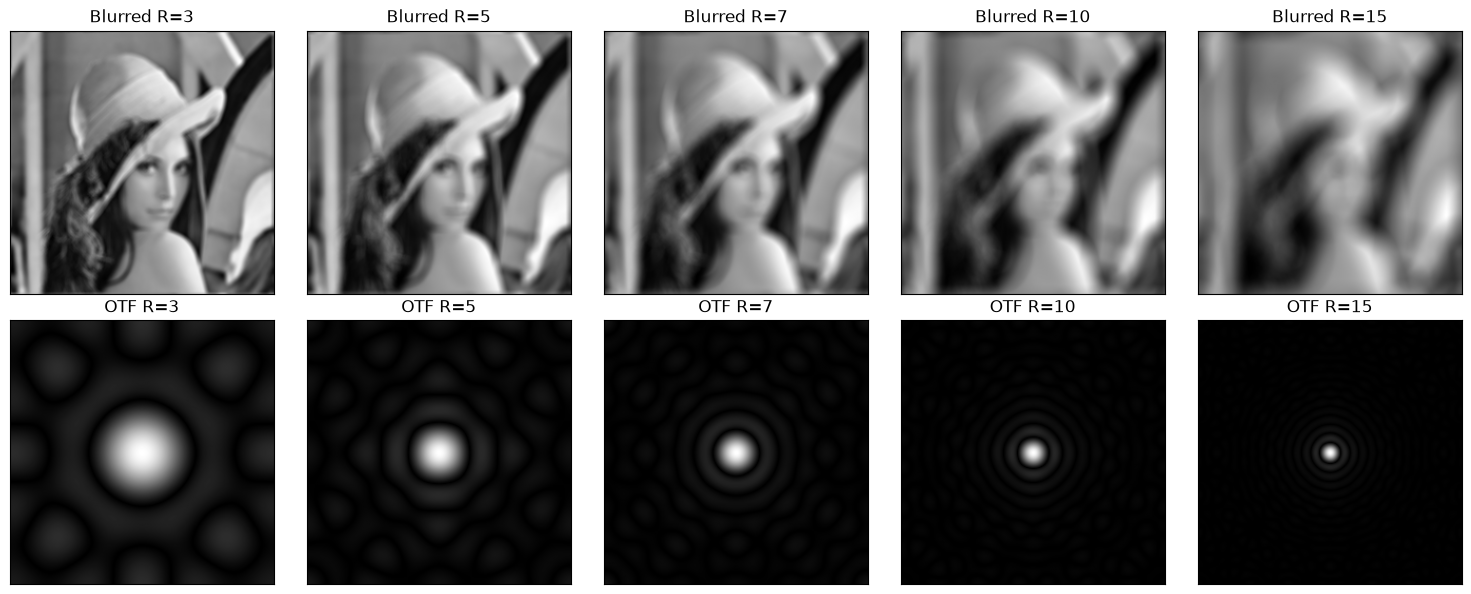

In [13]:
radii = [3, 5, 7, 10, 15]  # larger radius -> more blur and a more ill-conditioned (harder to invert) OTF

plt.figure(figsize=(15, 6))

for idx, r in enumerate(radii):

    H = out_of_focus_H(radius=r)
    g = np.abs(np.fft.ifft2(np.fft.ifftshift(IMG * H)))

    plt.subplot(2, len(radii), idx + 1)
    plt.imshow(g, cmap="gray")
    plt.title(f"Blurred R={r}")
    plt.xticks([]), plt.yticks([])

    plt.subplot(2, len(radii), len(radii) + idx + 1)
    plt.imshow(np.abs(H), cmap="gray")
    plt.title(f"OTF R={r}")
    plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

Comment: as the radius R increases, the disk PSF removes more high-frequency detail, so the
blurred image gets progressively softer. In the frequency domain, the OTF develops more
concentric zero-crossing rings that move closer to the origin, shrinking the band of frequencies
that survive with non-negligible magnitude. This means a naive inverse filter becomes
increasingly unstable as R grows, since more of the spectrum must be divided by values at or near
zero.